# Question 2: Student Performance Visualizations

Ingest -> preprocess -> analyze, then create V1-V5 and interpretation report.


In [51]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# Compact styling so text/legends fit within 800×600 at 300 DPI
sns.set_theme(style="whitegrid", context="paper", font_scale=0.01)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 4,
    "axes.titlesize": 4,
    "axes.labelsize": 4,
    "xtick.labelsize": 4,
    "ytick.labelsize": 4,
    "legend.fontsize": 4,
    "legend.title_fontsize": 4,
})

CWD = Path.cwd()
ROOT = CWD if (CWD / 'data_raw').exists() else CWD.parent
DATA_RAW_DIR = ROOT / 'data_raw'
DATA_CLEAN_DIR = ROOT / 'data_clean'
REPORT_DIR = ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'

DATA_CLEAN_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_WIDTH_PX = 800
TARGET_HEIGHT_PX = 600
RENDER_DPI = 300
OUTPUT_DPI = 300

# Matplotlib figsize is inches; pixels = inches * DPI
FIGSIZE = (TARGET_WIDTH_PX / OUTPUT_DPI, TARGET_HEIGHT_PX / OUTPUT_DPI)

print(f'Root: {ROOT}')
print(f'data_raw: {DATA_RAW_DIR}')
print(f'data_clean: {DATA_CLEAN_DIR}')
print(f'reports: {REPORT_DIR}')


Root: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2
data_raw: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/data_raw
data_clean: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/data_clean
reports: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports


## Ingest + Preprocess

In [52]:
students_path = DATA_RAW_DIR / 'StudentsPerformance.csv'
students = pd.read_csv(students_path)

students.columns = [c.strip().lower().replace(' ', '_') for c in students.columns]

score_cols = ['math_score', 'reading_score', 'writing_score']
for col in score_cols:
    students[col] = pd.to_numeric(students[col], errors='coerce')

missing_total = int(students.isna().sum().sum())

for col in students.columns:
    if students[col].isna().any():
        if pd.api.types.is_numeric_dtype(students[col]):
            students[col] = students[col].fillna(students[col].median())
        else:
            mode_val = students[col].mode(dropna=True)
            fill_val = mode_val.iloc[0] if not mode_val.empty else 'Unknown'
            students[col] = students[col].fillna(fill_val)

duplicates_before = int(students.duplicated().sum())
students = students.drop_duplicates().copy()
duplicates_after = int(students.duplicated().sum())

students['overall_avg'] = students[score_cols].mean(axis=1)

clean_students_path = DATA_CLEAN_DIR / 'students_performance_clean.csv'
students.to_csv(clean_students_path, index=False)

print(f'Loaded rows: {len(students)} from {students_path}')
print(f'Total missing values before imputation: {missing_total}')
print(f'Duplicates before drop: {duplicates_before}')
print(f'Duplicates after drop: {duplicates_after}')
print(f'Saved cleaned data: {clean_students_path}')
students.head()


Loaded rows: 1000 from /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/data_raw/StudentsPerformance.csv
Total missing values before imputation: 0
Duplicates before drop: 0
Duplicates after drop: 0
Saved cleaned data: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/data_clean/students_performance_clean.csv


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [53]:
def save_figure(filename, fig):
    out = FIG_DIR / filename

    fig.set_size_inches(FIGSIZE)
    fig.tight_layout()
    fig.savefig(out, dpi=RENDER_DPI, facecolor='white')
    plt.close(fig)

    with Image.open(out) as im:
        if im.size != (TARGET_WIDTH_PX, TARGET_HEIGHT_PX):
            im = im.resize((TARGET_WIDTH_PX, TARGET_HEIGHT_PX), Image.Resampling.LANCZOS)
        im.save(out, dpi=(OUTPUT_DPI, OUTPUT_DPI))

    if 'ipykernel' in sys.modules:
        from IPython.display import display, Image as IPyImage
        display(IPyImage(filename=str(out), width=800))

    print(f'Saved: {out}')
    return out


### V1 - Gender boxplots (math vs reading)

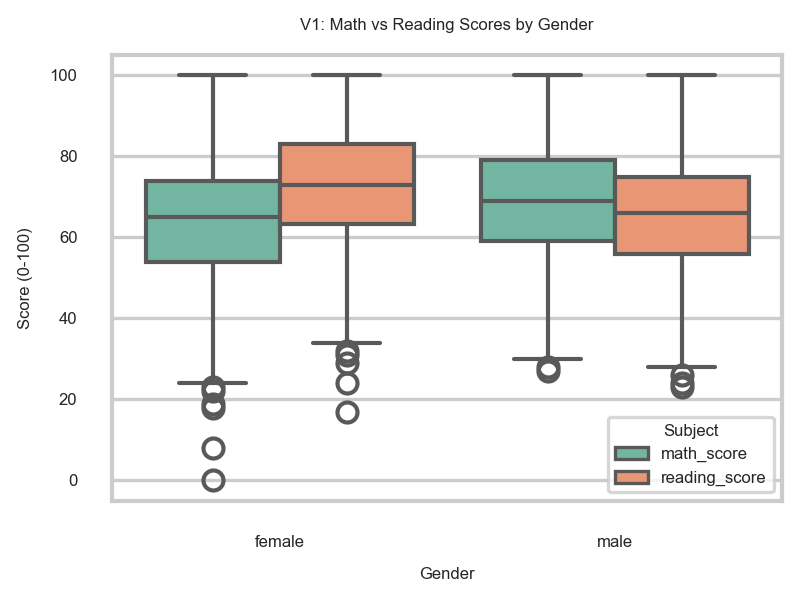

Saved: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/figures/v1_gender_boxplots.png


In [54]:
# a.Question: Are there gender differences in math vs reading?
# males are more good in math than reading
# females are more good in reading than math

v1_df = students.melt(
    id_vars='gender',
    value_vars=['math_score', 'reading_score'],
    var_name='subject',
    value_name='score'
)

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=RENDER_DPI)
sns.boxplot(data=v1_df, x='gender', y='score', hue='subject', palette='Set2', ax=ax)
ax.set_title('V1: Math vs Reading Scores by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Score (0-100)')
ax.legend(title='Subject', frameon=True)
v1_path = save_figure('v1_gender_boxplots.png', fig)


### V2 - Test prep impact on math

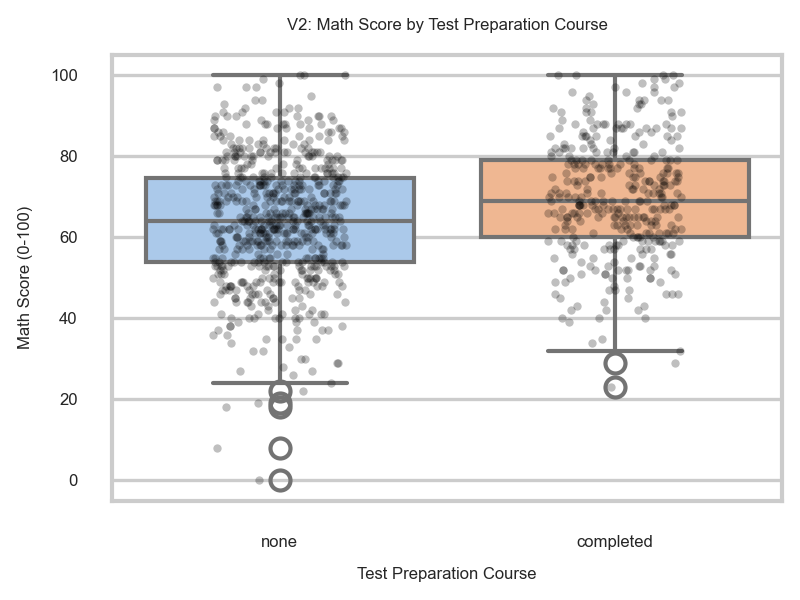

Saved: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/figures/v2_test_prep_math.png


In [55]:
# a.Question: Do students who completed test prep score higher in math?
# answer: Yes, the students who completed the test preparation scored higher in maths.
order = ['none', 'completed']
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=RENDER_DPI)

sns.boxplot(
    data=students,
    x='test_preparation_course',
    y='math_score',
    hue='test_preparation_course',
    order=order,
    dodge=False,
    palette='pastel',
    ax=ax
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

sns.stripplot(
    data=students,
    x='test_preparation_course',
    y='math_score',
    order=order,
    color='black',
    alpha=0.25,
    size=2,
    jitter=0.2,
    ax=ax
)

ax.set_title('V2: Math Score by Test Preparation Course')
ax.set_xlabel('Test Preparation Course')
ax.set_ylabel('Math Score (0-100)')
v2_path = save_figure('v2_test_prep_math.png', fig)


### V3 - Lunch type and average performance

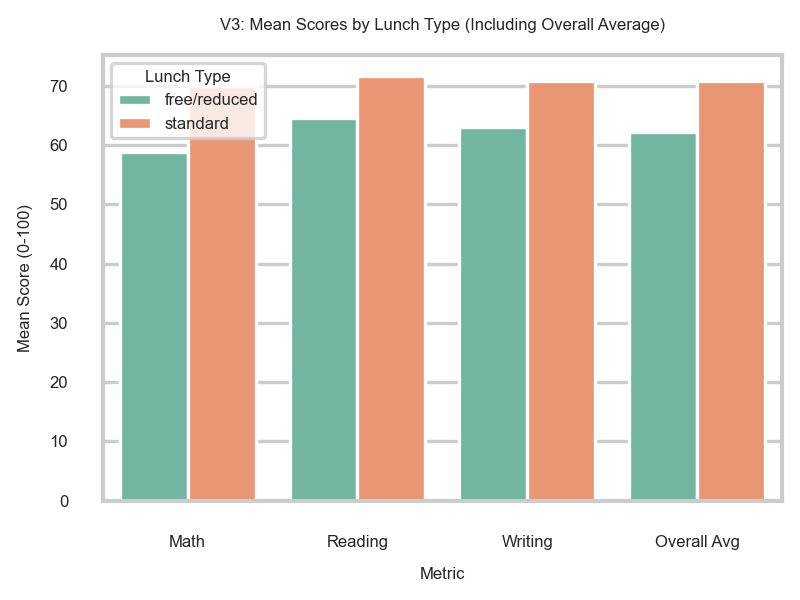

Saved: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/figures/v3_lunch_average_performance.png


In [56]:
# a.Question: Does lunch type (standard vs free/reduced) relate to outcomes?
# If they have standard lunch, their scores are higher.
lunch_means = (
    students
    .groupby('lunch', as_index=False)[['math_score', 'reading_score', 'writing_score', 'overall_avg']]
    .mean()
)

lunch_long = lunch_means.melt(id_vars='lunch', var_name='metric', value_name='mean_score')
metric_map = {
    'math_score': 'Math',
    'reading_score': 'Reading',
    'writing_score': 'Writing',
    'overall_avg': 'Overall Avg'
}
lunch_long['metric_label'] = lunch_long['metric'].map(metric_map)
metric_order = ['Math', 'Reading', 'Writing', 'Overall Avg']

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=RENDER_DPI)
sns.barplot(
    data=lunch_long,
    x='metric_label',
    y='mean_score',
    hue='lunch',
    order=metric_order,
    palette='Set2',
    ax=ax
)

ax.set_title('V3: Mean Scores by Lunch Type (Including Overall Average)')
ax.set_xlabel('Metric')
ax.set_ylabel('Mean Score (0-100)')
ax.legend(title='Lunch Type', frameon=True)
v3_path = save_figure('v3_lunch_average_performance.png', fig)


### V4 - Subject correlations

Overall (mean pairwise correlation): 0.8582732622560364


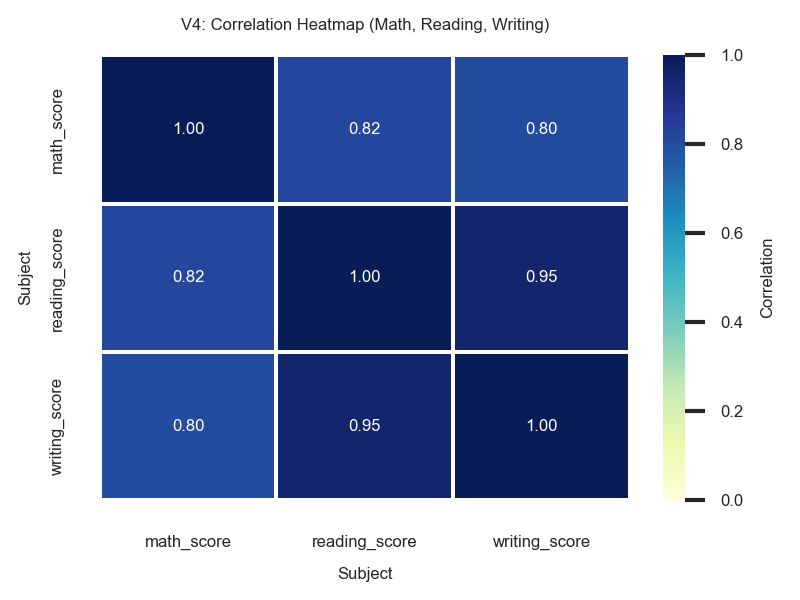

Saved: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/figures/v4_subject_correlations.png


In [57]:
# a.Question: How strongly do the three subjects move together?
# The three subjects are strongly correlated. Math–Reading = 0.82, Math–Writing = 0.80, and Reading–Writing = 0.95 (strongest). The average pairwise correlation is 0.86, so students who score high in one subject usually score high in the others.

corr_mat = students[['math_score','reading_score','writing_score']].corr()

# mean of the 3 unique pairwise correlations
overall_corr = corr_mat.where(~np.eye(corr_mat.shape[0], dtype=bool)).stack().mean()

print("Overall (mean pairwise correlation):", overall_corr)

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=RENDER_DPI)
sns.heatmap(
    corr_mat,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'},
    annot_kws={'size': 4},
    ax=ax
)
ax.set_title('V4: Correlation Heatmap (Math, Reading, Writing)')
ax.set_xlabel('Subject')
ax.set_ylabel('Subject')
v4_path = save_figure('v4_subject_correlations.png', fig)


### V5 - Math vs reading with trend lines by test prep

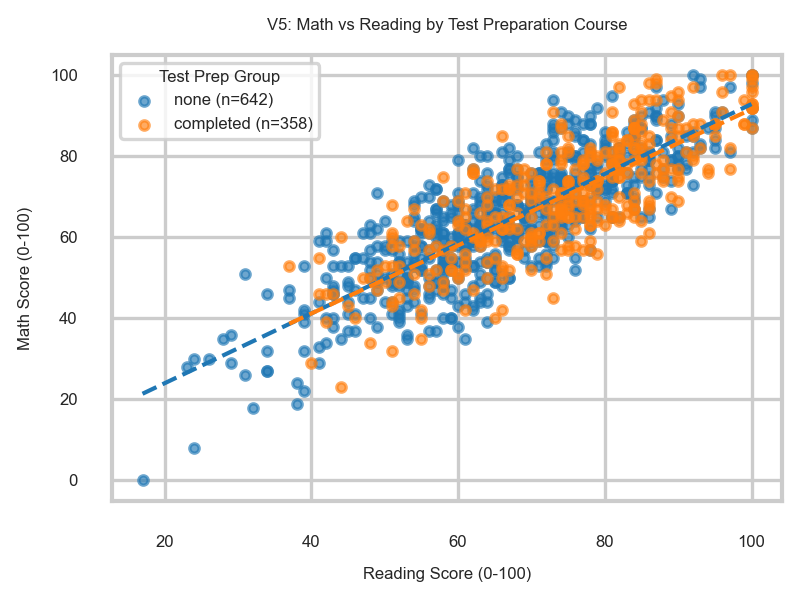

Saved: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/figures/v5_math_vs_reading_trendlines.png
Overall corr(reading,math): 0.818
                             n  corr(reading,math)  slope(math~reading)  \
test_preparation_course                                                   
completed                358.0               0.793                0.840   
none                     642.0               0.820                0.861   

                         mean_math  mean_reading  
test_preparation_course                           
completed                   69.696        73.894  
none                        64.078        66.534  


In [58]:
# a.Question: How strongly are math and reading scores associated, and do students who completed the test‑preparation course have a different slope in the math–reading relationship than those who did not?

#  Math and reading scores are strongly positively associated overall (r = 0.818). The relationship is strong in both groups: none has r = 0.820 with slope 0.861 (n=642) and completed has r = 0.793 with slope 0.840 (n=358). The slopes/correlations are very similar, so test prep does not meaningfully change the strength of the math–reading relationship; instead, the completed group is shifted higher on average (mean math 69.70 vs 64.08; mean reading 73.89 vs 66.53), indicating higher scores at comparable levels.
palette = {'none': '#1f77b4', 'completed': '#ff7f0e'}
slopes = {}
counts = {}
correlations = {}

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=RENDER_DPI)
for group in ['none', 'completed']:
    gdf = students[students['test_preparation_course'] == group]
    counts[group] = len(gdf)
    correlations[group] = gdf['reading_score'].corr(gdf['math_score'])

    ax.scatter(
        gdf['reading_score'],
        gdf['math_score'],
        alpha=0.65,
        s=5,
        color=palette[group],
        label=f'{group} (n={len(gdf)})'
    )

    slope, intercept = np.polyfit(gdf['reading_score'], gdf['math_score'], 1)
    slopes[group] = slope

    x_line = np.array([gdf['reading_score'].min(), gdf['reading_score'].max()])
    y_line = slope * x_line + intercept
    ax.plot(
        x_line,
        y_line,
        color=palette[group],
        linewidth=1,
        linestyle='--',
        label='_nolegend_'
    )

ax.set_title('V5: Math vs Reading by Test Preparation Course')
ax.set_xlabel('Reading Score (0-100)')
ax.set_ylabel('Math Score (0-100)')
ax.legend(title='Test Prep Group', frameon=True)
v5_path = save_figure('v5_math_vs_reading_trendlines.png', fig)

# Overall association
overall_corr = students["reading_score"].corr(students["math_score"])

# Grouped association + slopes + means
summary_v5 = (
    students.groupby("test_preparation_course")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "corr(reading,math)": g["reading_score"].corr(g["math_score"]),
        "slope(math~reading)": np.polyfit(g["reading_score"], g["math_score"], 1)[0],
        "mean_math": g["math_score"].mean(),
        "mean_reading": g["reading_score"].mean(),
    }))
)

print("Overall corr(reading,math):", round(overall_corr, 3))
print(summary_v5.round(3))


### Report writing

In [59]:
v1_medians = students.groupby('gender')[['math_score', 'reading_score']].median()
v2_means = students.groupby('test_preparation_course')['math_score'].mean()
v3_overall = students.groupby('lunch')['overall_avg'].mean()

interp_lines = [
    '# Visualization Interpretations',
    '',
    '## V1 - Gender boxplots (math vs reading)',
    'Question: Are there gender differences in math vs reading?',
    f"Median math: female={v1_medians.loc['female', 'math_score']:.1f}, male={v1_medians.loc['male', 'math_score']:.1f}.",
    f"Median reading: female={v1_medians.loc['female', 'reading_score']:.1f}, male={v1_medians.loc['male', 'reading_score']:.1f}.",
    'Interpretation: males tend to score higher in math, while females tend to score higher in reading; differences are moderate with overlap.',
    '',
    '## V2 - Test prep impact on math',
    'Question: Do students who completed test prep score higher in math?',
    f"Mean math (none)={v2_means.loc['none']:.2f}, (completed)={v2_means.loc['completed']:.2f}.",
    f"Difference (completed - none)={v2_means.loc['completed'] - v2_means.loc['none']:.2f} points.",
    'Interpretation: completion is associated with higher math scores, although both groups have wide ranges and overlap.',
    '',
    '## V3 - Lunch type and average performance',
    'Question: Does lunch type (standard vs free/reduced) relate to outcomes?',
    f"Overall average: standard={v3_overall.loc['standard']:.2f}, free/reduced={v3_overall.loc['free/reduced']:.2f}.",
    f"Gap (standard - free/reduced)={v3_overall.loc['standard'] - v3_overall.loc['free/reduced']:.2f} points.",
    'Interpretation: standard lunch is associated with higher performance across subjects (association, not causation).',
    '',
    '## V4 - Subject correlations',
    'Question: How strongly do the three subjects move together?',
    f"Math–Reading r={corr_mat.loc['math_score', 'reading_score']:.2f}; "
    f"Math–Writing r={corr_mat.loc['math_score', 'writing_score']:.2f}; "
    f"Reading–Writing r={corr_mat.loc['reading_score', 'writing_score']:.2f}.",
    f"Average pairwise correlation={overall_corr:.2f}.",
    'Interpretation: correlations are high and positive; reading and writing move most closely together.',
    '',
    '## V5 - Math vs reading with trend lines by test prep',
    'Question: How strongly are math and reading scores associated, and does test prep change the slope?',
    f"None: n={counts['none']}, slope={slopes['none']:.2f}, r={correlations['none']:.2f}.",
    f"Completed: n={counts['completed']}, slope={slopes['completed']:.2f}, r={correlations['completed']:.2f}.",
    'Interpretation: both groups show a strong positive association and very similar slopes; prep status mainly shifts scores upward rather than changing the relationship strength.',
]

viz_report_path = REPORT_DIR / 'visualization_interpretations.md'
viz_report_path.write_text('\n'.join(interp_lines), encoding='utf-8')
print(f'Saved report: {viz_report_path}')


Saved report: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/visualization_interpretations.md


In [60]:
for p in [v1_path, v2_path, v3_path, v4_path, v5_path]:
    with Image.open(p) as im:
        print(f"{p.name}: size={im.size}, dpi={im.info.get('dpi')}")

print('Generated files:')
print('-', DATA_RAW_DIR / 'StudentsPerformance.csv')
print('-', DATA_CLEAN_DIR / 'students_performance_clean.csv')
print('-', REPORT_DIR / 'visualization_interpretations.md')
print('-', FIG_DIR)


v1_gender_boxplots.png: size=(800, 600), dpi=(299.9994, 299.9994)
v2_test_prep_math.png: size=(800, 600), dpi=(299.9994, 299.9994)
v3_lunch_average_performance.png: size=(800, 600), dpi=(299.9994, 299.9994)
v4_subject_correlations.png: size=(800, 600), dpi=(299.9994, 299.9994)
v5_math_vs_reading_trendlines.png: size=(800, 600), dpi=(299.9994, 299.9994)
Generated files:
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/data_raw/StudentsPerformance.csv
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/data_clean/students_performance_clean.csv
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/visualization_interpretations.md
- /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_1/Question2/reports/figures
